# AHaH Attractors — the unsupervised lesson

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/knowm/ktram-neural-core/blob/main/python/examples/ahah-attractors/ahah_attractors.ipynb)

The runnable companion to *Chapter 5: AHaH Attractors*. Everything here runs on a tiny
**neural lane**: a couple of differential pairs (kT-bits) read through one 2-1 divider. We give it
random AATs, read (`FF`) and feed back unsupervised (`RU`) — the AHaH cycle — and watch the
weights fall into attractor states all on their own. No labels, no loss function.

Then we do what the article does: add the overlapping pattern and watch the **null state**
swallow the node, break it with an `RA` **bias** and the split write, name each state by what
the node *does* (its **fingerprint**), and discover that every attractor is one of the sixteen
two-input **logic gates**.

The seeds are there to be changed. Change `init`, `model`, the patterns, the bias count, and
the step count, and watch where the synapses settle.

## Setup

On Colab this installs the package from GitHub. Locally it is a no-op if already installed.

In [1]:
# On Colab this installs the package from GitHub. Locally it is a no-op if already installed.
try:
    import ktram_neural_core  # noqa: F401
except ModuleNotFoundError:
    %pip install -q "git+https://github.com/knowm/ktram-neural-core.git#subdirectory=python" matplotlib

In [14]:
import collections
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from ktram_neural_core import Core

BLUE, ORANGE, GREEN, RED, GREY = "tab:blue", "tab:orange", "tab:green", "tab:red", "0.55"
GRID = "0.92"

# A 2-synapse AHaH node is a lane with TWO address spaces — one differential pair per space.
# The AAT selects which synapses are coupled to the shared 2-1 readout:
P0  = (0, None)   # synapse 0 alone        "[0]"
P1  = (None, 0)   # synapse 1 alone        "[1]"
P01 = (0, 0)      # both synapses coupled   "[0,1]"

def node_core(spaces=2, model='float', init='medium', seed=0):
    # 1x1 unit crossbars (one device per side per space); read noise off so we watch the
    # deterministic attractor dynamics, not the thermal hiss.
    return Core(1, 1, spaces_per_lane=spaces, num_lanes=1,
                model=model, init=init, seed=seed, read_noise=0.0)

def w(core, space, n_spaces=2):
    """Weight of one synapse, read on its own:  w = (Ga - Gb) / (Ga + Gb) in [-1, 1]."""
    aat = [None] * n_spaces
    aat[space] = 0
    ga, gb = core.read_gab(0, tuple(aat))
    return (ga - gb) / (ga + gb)

def run_node(seed, patterns, n=300, model='float', init='medium'):
    """Drive a 2-synapse node with the AHaH cycle (FF then RU) on random AATs.
    Returns (core, w0_path, w1_path) with the random start point included."""
    core = node_core(2, model, init, seed)
    lane = core.lane(0)
    rng = np.random.default_rng(seed)
    w0, w1 = [w(core, 0)], [w(core, 1)]
    for _ in range(n):
        p = patterns[rng.integers(len(patterns))]
        lane.evaluate(p, 'FF')          # read  (forward, full)
        lane.evaluate(p, 'RU')          # unsupervised feedback (reverse, Hebbian)
        w0.append(w(core, 0)); w1.append(w(core, 1))
    return core, np.array(w0), np.array(w1)

def classify(core):
    """The attractor-state label from three non-disturbing reads (FFLV), per the AHaH paper.
    The sign triple over [0], [1], [0,1] maps to A/A', B/B', C/C', D/D'."""
    lane = core.lane(0)
    s = tuple(int(np.sign(lane.evaluate(p, 'FFLV'))) for p in (P0, P1, P01))
    return {(-1,-1,-1):'A', (1,1,1):"A'", (-1,1,-1):'B', (1,-1,1):"B'",
            (-1,1,1):'C', (1,-1,-1):"C'", (1,1,-1):'D', (-1,-1,1):"D'"}.get(s, '?')

def quad_color(w0, w1):
    return {(1,1):ORANGE, (-1,-1):ORANGE, (1,-1):BLUE, (-1,1):BLUE}[
        (int(np.sign(w0)), int(np.sign(w1)))]

## Two synapses, three AATs

The lane has two spaces, so an AAT has two slots. `P0 = (0, None)` couples only synapse 0 to
the readout; `P1 = (None, 0)` only synapse 1; `P01 = (0, 0)` couples both, and the divider
hands back their activity-weighted average. Read each with a non-disturbing `FFLV` and you get
the weight that slot is carrying.

The drive is two instructions per step, and the two halves are where **AHaH** — *anti-Hebbian
and Hebbian* — gets its name. `FF` floats the output and reports the node's state while pulling
it weakly toward zero (anti-Hebbian); `RU` takes its direction from that read and pushes the
weight further the way it was already leaning (Hebbian). Read, then reinforce. Nobody supplies a
label; the node's own output is the teacher in the loop.

In [3]:
core = node_core(2, 'float', 'medium', seed=3)
lane = core.lane(0)
for name, p in [('P0  [0]  ', P0), ('P1  [1]  ', P1), ('P01 [0,1]', P01)]:
    print(f'{name}  AAT={str(p):11s}  y = {lane.evaluate(p, "FFLV"):+.4f}')
print(f'\nsynapse 0 weight w0 = {w(core,0):+.4f}    synapse 1 weight w1 = {w(core,1):+.4f}')

P0  [0]    AAT=(0, None)    y = +0.2359
P1  [1]    AAT=(None, 0)    y = +0.0497
P01 [0,1]  AAT=(0, 0)       y = +0.1419

synapse 0 weight w0 = +0.2359    synapse 1 weight w1 = +0.0497


## Orthogonal inputs → four attractors

Drive the node with only `P0` and `P1` (never both at once). Each synapse is read and
reinforced entirely on its own — they never interact. A synapse nudged a little positive
gets *more* positive; a little negative gets *more* negative. Two synapses × two signs =
**2² = 4 attractors**, one per sign quadrant. Start a few hundred nodes near the origin
(`medium` init) and watch each one radiate to its corner. Which corner it lands in was set by
the luck of its initial conductances — unsupervised AHaH learning in its simplest form: a
weakly-broken symmetry, reinforced until it commits.

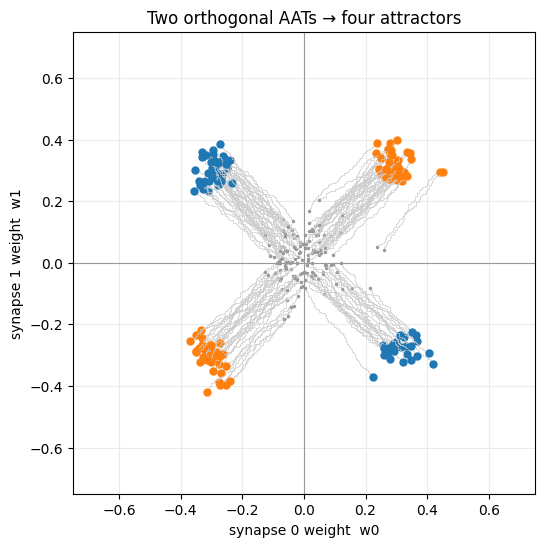

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
for s in range(140):
    _, w0, w1 = run_node(s, [P0, P1], n=300)
    ax.plot(w0, w1, color='0.8', lw=0.5)
    ax.plot(w0[0], w1[0], '.', color='0.6', ms=3)
    ax.plot(w0[-1], w1[-1], 'o', color=quad_color(w0[-1], w1[-1]), ms=5)
ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
ax.set_xlim(-.75, .75); ax.set_ylim(-.75, .75); ax.set_aspect('equal')
ax.set_xlabel('synapse 0 weight  w0'); ax.set_ylabel('synapse 1 weight  w1')
ax.set_title('Two orthogonal AATs → four attractors'); ax.grid(True, color=GRID)
plt.show()

### Aside: the same four basins on real devices

Swap the device model with one word. The four basins land in the same place on every one —
the computation is in the AAT cycle, not the device. `float` is infinitely fine; `byte` snaps
to an 8-bit staircase; `mss` and `rs` are accurate stochastic models of real Knowm
memristors. Resolution and scatter change; the four attractors do not. (This device sweep is
not in the article — it is here because it is the kT-bit point from Chapters 3b and 4b, made
visible.)

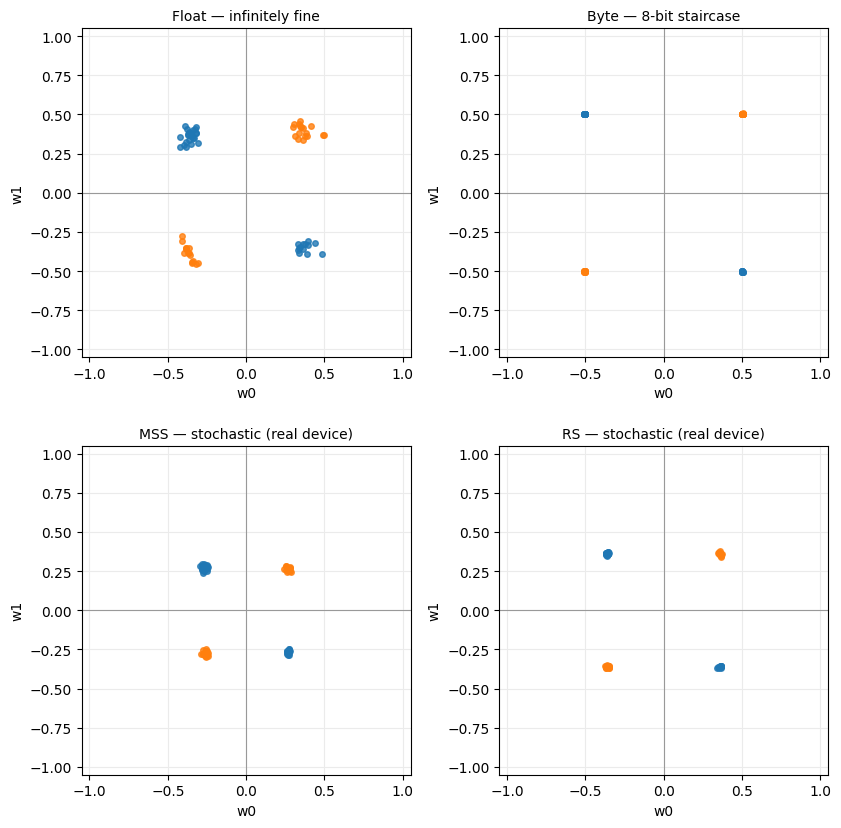

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.5))
for a, (model, title) in zip(axes.flat,
        [('float','Float — infinitely fine'), ('byte','Byte — 8-bit staircase'),
         ('mss','MSS — stochastic (real device)'), ('rs','RS — stochastic (real device)')]):
    for s in range(70):
        _, w0, w1 = run_node(s, [P0, P1], n=400, model=model)
        a.plot(w0[-1], w1[-1], 'o', color=quad_color(w0[-1], w1[-1]), ms=4, alpha=0.8)
    a.axhline(0, color='0.6', lw=0.8); a.axvline(0, color='0.6', lw=0.8)
    a.set_xlim(-1.05, 1.05); a.set_ylim(-1.05, 1.05); a.set_aspect('equal')
    a.set_title(title, fontsize=10); a.set_xlabel('w0'); a.set_ylabel('w1')
    a.grid(True, color=GRID)
plt.tight_layout(); plt.show()

## Non-orthogonal inputs → the null state

Now let the third AAT in, `P01`, which couples both synapses to the readout at once, and drive
the node with all three patterns at random. The moment two synapses are read *and fed back as
one*, they stop being independent.

Once they interact, the quadrant label stops being useful, so describe the node by its
**decision boundary** — the line where its answer flips. The output is $y = x_0 w_0 + x_1 w_1$,
so the boundary is $x_0 w_0 + x_1 w_1 = 0$, a line **through the origin** (no constant term).
There are three patterns to slice — `[1,0]`, `[0,1]`, `[1,1]` — because an input that never
arrives carries nothing to learn from. Each distinct way the line splits those three is a state:
A, B, C and their anti-states, with a fourth slot D the bias-free node can never reach.

Run a few hundred and count. Most slide onto the `w0 = w1` diagonal where the two synapses
agree (both positive or both negative): state **A** and its anti-state **A'**, the **null
state**. It answers every pattern the same way and it is greedy, taking roughly two-thirds of
the nodes. A few escape to B and C at the edges. **D never forms** — it would mean answering
`[1,1]` differently from both single-input patterns, which takes a boundary that misses the
origin, and a bias-free node has none. This is "the rich get richer" in a two kT-bit node: the
easiest agreement to reach swallows everything else.

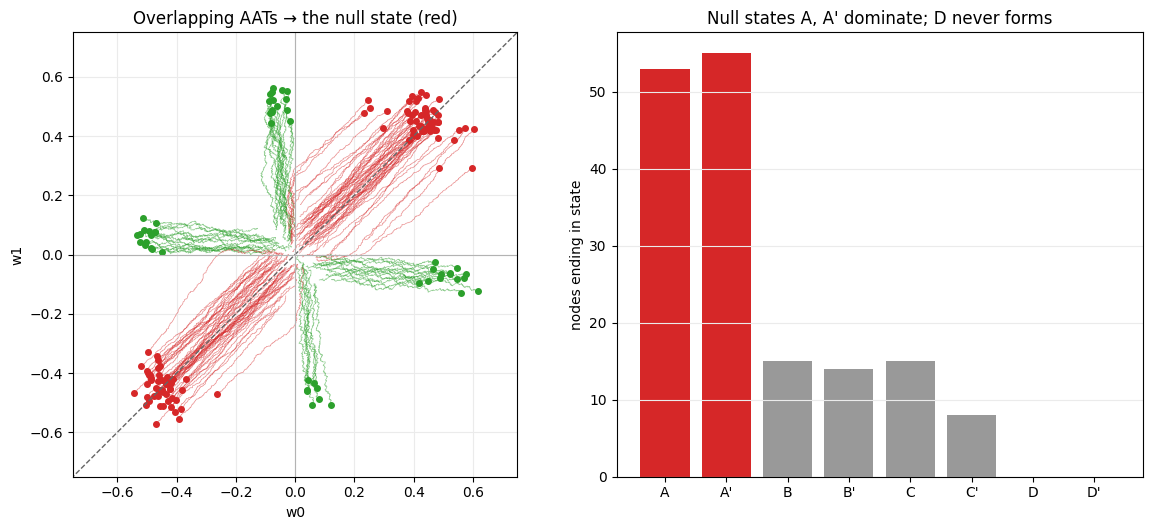

state occupancy: {"A'": 55, 'C': 15, "C'": 8, 'A': 53, 'B': 15, "B'": 14}


In [6]:
fig, (axp, axb) = plt.subplots(1, 2, figsize=(12, 5.4))
counts = collections.Counter()
for s in range(160):
    core, w0, w1 = run_node(s, [P0, P1, P01], n=400)
    null = np.sign(w0[-1]) == np.sign(w1[-1])
    col = RED if null else GREEN
    axp.plot(w0, w1, color=col, lw=0.5, alpha=0.5)
    axp.plot(w0[-1], w1[-1], 'o', color=col, ms=4)
    counts[classify(core)] += 1
axp.plot([-1, 1], [-1, 1], '--', color='0.4', lw=1.0)   # the null diagonal
axp.axhline(0, color='0.7', lw=0.8); axp.axvline(0, color='0.7', lw=0.8)
axp.set_xlim(-.75, .75); axp.set_ylim(-.75, .75); axp.set_aspect('equal')
axp.set_xlabel('w0'); axp.set_ylabel('w1')
axp.set_title('Overlapping AATs → the null state (red)'); axp.grid(True, color=GRID)

order = ['A', "A'", 'B', "B'", 'C', "C'", 'D', "D'"]
axb.bar(order, [counts.get(k, 0) for k in order],
        color=[RED if k in ('A', "A'") else '0.6' for k in order])
axb.set_ylabel('nodes ending in state')
axb.set_title("Null states A, A' dominate; D never forms"); axb.grid(True, axis='y', color=GRID)
plt.tight_layout(); plt.show()
print('state occupancy:', dict(counts))

## The state we never reached, and the bias that reaches it

D is off the table because the node can only draw a line **through the origin** — its output
$y = x_0 w_0 + x_1 w_1$ has no constant term. To slide the boundary off the origin you need a
constant added to every read regardless of the inputs. That is a **bias**: an extra synapse
that fires on every pattern, so the output becomes $y = x_0 w_0 + x_1 w_1 + b$ and the line can
cross zero somewhere other than the origin.

You cannot just bolt on an always-on synapse and train it with `RU` like the others — it would
become one more vote for whatever the node already says and dig the null *deeper*. So we **split
the feedback**:

- `FF` reads the whole node once, **bias included**.
- `RU` feeds back on the input synapses (Hebbian, with the output).
- `RA` feeds back on the bias (anti-Hebbian, the same reverse write with its sign flipped, so
  the bias is pushed *against* the output).

Read once, Hebbian on the inputs, anti-Hebbian on the bias. The state we read off is the
**output** fingerprint — the sign of $y$ on `[0]`, `[1]`, `[0,1]` *with the bias in the read* —
not the input weight signs, which no longer tell you where the boundary sits.

In [7]:
# A bias is one or more always-on synapses appended after the two inputs. The split write reads
# the whole node once (FF), then drives the inputs with RU (Hebbian) and the bias with RA
# (anti-Hebbian) off that same read. The STATE is the 3-bit output fingerprint, with the bias in
# the read, mapped to A..D'. (Once a bias offsets the boundary you cannot read state from weight
# signs, so we read it from what the node does.)
BIAS_STATE = {0:'A', 1:"D'", 2:'B', 3:'C', 4:"C'", 5:"B'", 6:'D', 7:"A'"}

def split_write_run(seed, n_bias, init, n_steps, track=False):
    """One node: 2 inputs + n_bias always-on bias synapses, driven by the split write.
    Returns (state, path): state is the 3-bit output fingerprint, path the weight trajectory
    array (n_sp, n_steps+1) when track else None."""
    n_sp = 2 + n_bias
    core = Core(1, 1, spaces_per_lane=n_sp, num_lanes=1, model='float',
                init=init, seed=seed, read_noise=0.0)
    lane = core.lane(0)
    rng = np.random.default_rng(seed)
    keys = ['0', '1', '01']

    def full(k):                       # FF read: active inputs + every bias
        a = [None] * n_sp
        if k != '1': a[0] = 0
        if k != '0': a[1] = 0
        for b in range(2, n_sp): a[b] = 0
        return tuple(a)

    def inputs(k):                     # RU: active inputs only
        a = [None] * n_sp
        if k != '1': a[0] = 0
        if k != '0': a[1] = 0
        return tuple(a)

    aat_bias = tuple(0 if i >= 2 else None for i in range(n_sp))   # RA: bias synapses only

    def wt(sp):
        a = [None] * n_sp; a[sp] = 0
        ga, gb = core.read_gab(0, tuple(a))
        return (ga - gb) / (ga + gb)

    path = [[wt(j)] for j in range(n_sp)] if track else None
    for _ in range(n_steps):
        k = keys[rng.integers(3)]
        lane.evaluate(full(k), 'FF')        # read the whole node (bias included)
        lane.evaluate(inputs(k), 'RU')      # Hebbian on the inputs
        lane.evaluate(aat_bias, 'RA')       # anti-Hebbian on the bias
        if track:
            for j in range(n_sp): path[j].append(wt(j))
    bits = [1 if lane.evaluate(full(k), 'FFLV') >= 0 else 0 for k in keys]
    state = (bits[0] << 2) | (bits[1] << 1) | bits[2]
    return state, (np.array(path) if track else None)

def show_split_write(n_bias, init, title, n_nodes=500, n_steps=2000, sample=120):
    """Left: weights over time (inputs + bias). Right: the output-state histogram (A..D')."""
    states, paths = [], []
    for s in range(n_nodes):
        st, pth = split_write_run(s, n_bias, init, n_steps, track=(s < sample))
        states.append(st)
        if pth is not None: paths.append(pth)
    states = np.array(states)
    counts = collections.Counter(states.tolist())
    bias_cols = [GREEN, 'tab:purple']

    fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.0))
    for p in paths[::6]:
        t = np.arange(p.shape[1])
        ax[0].plot(t, p[0], color=BLUE, lw=0.5, alpha=0.5)
        ax[0].plot(t, p[1], color=ORANGE, lw=0.5, alpha=0.5)
        for b in range(n_bias):
            ax[0].plot(t, p[2 + b], color=bias_cols[b % 2], lw=0.6, alpha=0.4)
    ax[0].axhline(0, color='0.6', lw=0.8); ax[0].set_ylim(-1.05, 1.05)
    ax[0].set_xlabel('step'); ax[0].set_ylabel('weight'); ax[0].set_title('Weights over time')
    handles = [Line2D([], [], color=BLUE, label='$w_0$ (input)'),
               Line2D([], [], color=ORANGE, label='$w_1$ (input)')]
    for b in range(n_bias):
        handles.append(Line2D([], [], color=bias_cols[b % 2],
                              label='bias' if n_bias == 1 else f'bias {b + 1}'))
    ax[0].legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.9, ncol=2)
    ax[0].grid(True, color=GRID)

    vals = [counts.get(i, 0) for i in range(8)]
    col = lambda i: RED if i in (0, 7) else (GREEN if i in (1, 6) else '0.6')
    ax[1].bar(range(8), vals, color=[col(i) for i in range(8)])
    ax[1].set_xticks(range(8))
    ax[1].set_xticklabels([f'{BIAS_STATE[i]}\n{i:03b}' for i in range(8)], fontsize=9)
    ax[1].set_xlabel('state   (output sign on  [0], [1], [0,1])'); ax[1].set_ylabel('nodes')
    ax[1].set_title('Where the nodes land')
    ax[1].legend(handles=[Patch(color=RED, label='null (A/A′)'),
                          Patch(color=GREEN, label='D / D′'),
                          Patch(color='0.6', label='B / B′ / C / C′')],
                 loc='upper right', fontsize=8, framealpha=0.9)
    ax[1].grid(True, axis='y', color=GRID)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()

    null = int(np.isin(states, [0, 7]).sum())
    print(f'n_bias={n_bias} init={init}: null={null}/{n_nodes}={null/n_nodes:.0%}   ' +
          '  '.join(f'{BIAS_STATE[i]}={counts.get(i, 0)}' for i in range(8)))

### One bias: the null state breaks

One always-on bias, trained with the split write. The null states A and A' — the all-one-answer
states that had swallowed two-thirds of the nodes — are **empty**. But D and D' are empty too:
a single low-magnitude bias is enough to break the null collapse, and not enough to carve the
off-origin boundary D actually needs. On the left the inputs rail to ±1 while the bias settles
between them.

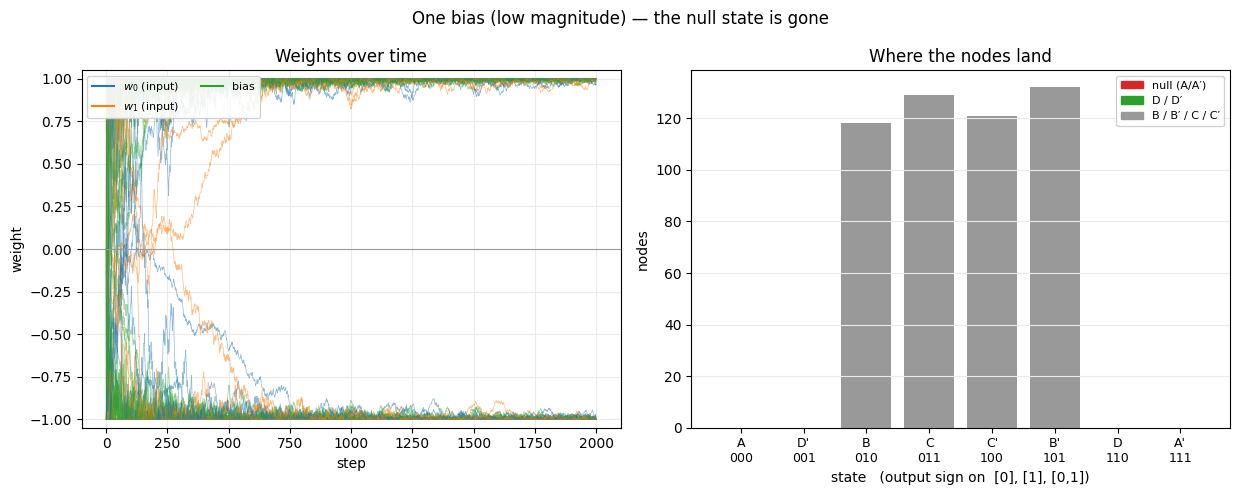

n_bias=1 init=low: null=0/500=0%   A=0  D'=0  B=118  C=129  C'=121  B'=132  D=0  A'=0


In [8]:
show_split_write(1, 'low', 'One bias (low magnitude) — the null state is gone')

### Two biases: D and D' appear

Reaching D means flipping the `[0,1]` answer away from what both single-input patterns say, and
the readout is a magnitude-weighted average, so the bias has to outweigh *both* inputs at once.
One low-magnitude bias does not carry that much of the vote, so add a second. Now D and D'
both appear for the first time — two biases together carry enough weight to tip the combined
read either way. Their basins are still small, but no longer empty.

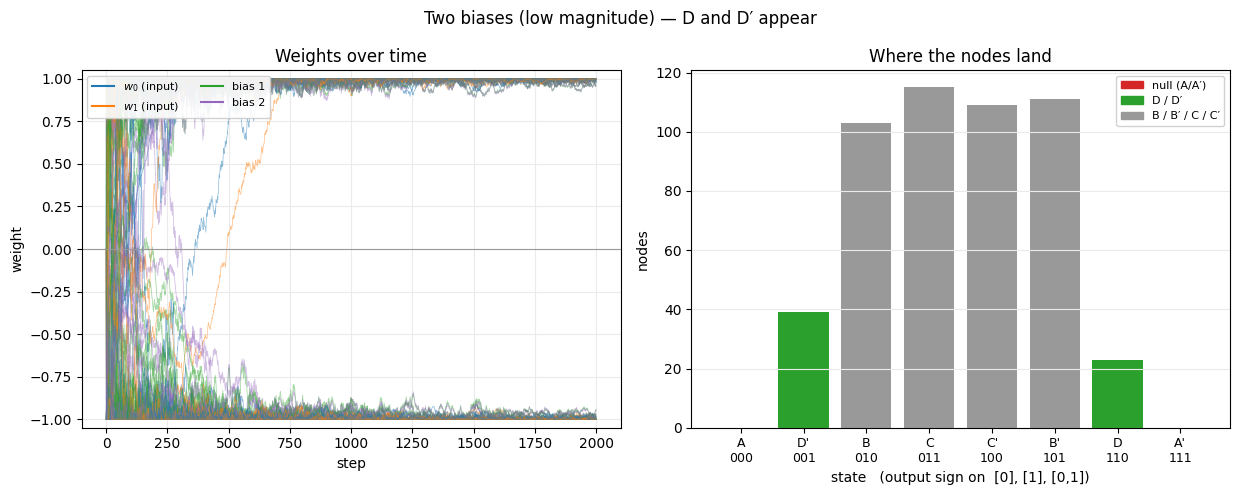

n_bias=2 init=low: null=0/500=0%   A=0  D'=39  B=103  C=115  C'=109  B'=111  D=23  A'=0


In [9]:
show_split_write(2, 'low', 'Two biases (low magnitude) — D and D′ appear')

### The bias has a reach

What sets how far the bias can move the boundary is its **magnitude** — the same magnitude that
was inertia and evidence back in Chapter 3b. More conductance behind the bias, the further off
the origin the line can sit. Raise the initialization magnitude (`medium`) and run it again: the
D and D' basins fill out, and the six non-null states settle into a balanced set with the null
gone. With enough magnitude behind the bias, the node reaches the whole landscape the bias-free
version had locked away.

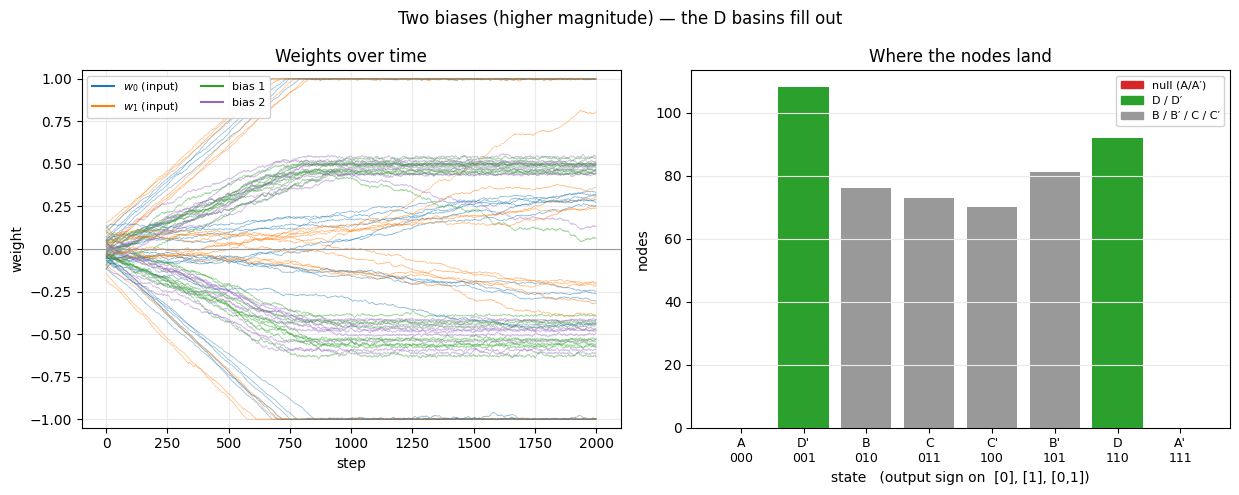

n_bias=2 init=medium: null=0/500=0%   A=0  D'=108  B=76  C=73  C'=70  B'=81  D=92  A'=0


In [10]:
show_split_write(2, 'medium', 'Two biases (higher magnitude) — the D basins fill out')

## Telling one attractor from another: the fingerprint

Reading state off a weight-space plot only works for two synapses. A bias node has three or four
synapses and no plot to draw, and the same two bits can be wired onto two synapses or four, so no
single set of axes holds every version. So stop watching the weights and watch what the node
*does*: hand it each pattern, run a non-disturbing `FFLV` read, and write the signs down in
order. Read `+` as 1 and `−` as 0 and that tuple is a number — the state's name. It never looks
at a synapse, so it works the same for two synapses or two hundred.

```python
fingerprint = tuple(int(np.sign(lane.evaluate(p, "FFLV"))) for p in patterns)
```

Try it on the four-corner node. It sees two patterns, `[0]` and `[1]`, so its fingerprint is a
two-bit number with four values — and those four values are the four corners from the first
plot, recovered without drawing anything.

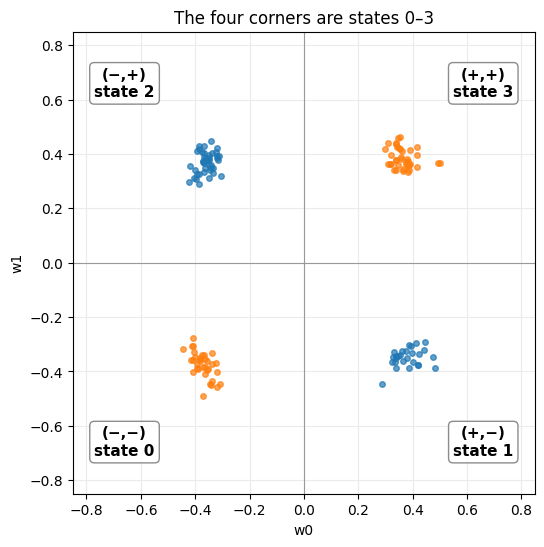

In [11]:
def H(y):
    """One output bit: + (>=0) -> 1, - -> 0. The atom of the fingerprint."""
    return 1 if y >= 0 else 0

fig, ax = plt.subplots(figsize=(6, 6))
for s in range(140):
    core, w0, w1 = run_node(s, [P0, P1], n=400)
    ax.plot(w0[-1], w1[-1], 'o', color=quad_color(w0[-1], w1[-1]), ms=4, alpha=0.7, zorder=2)
# the fingerprint of the converged node: (sign y[0], sign y[1]) -> 2-bit number
for (x, y), sgn, idx in [((-.66,-.66),'(−,−)',0), ((.66,-.66),'(+,−)',1),
                         ((-.66,.66),'(−,+)',2), ((.66,.66),'(+,+)',3)]:
    ax.text(x, y, f'{sgn}\nstate {idx}', ha='center', va='center', fontsize=11,
            fontweight='bold', zorder=4,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.5', alpha=0.9))
ax.axhline(0, color='0.6', lw=0.8); ax.axvline(0, color='0.6', lw=0.8)
ax.set_xlim(-.85, .85); ax.set_ylim(-.85, .85); ax.set_aspect('equal')
ax.set_xlabel('w0'); ax.set_ylabel('w1')
ax.set_title('The four corners are states 0–3'); ax.grid(True, color=GRID)
plt.show()

## Counting them, and three ways to wire the same two bits

With a name for every state, two impossible questions become bookkeeping: how many distinct
states does a node settle into (the number of bars), and how big is each basin (the height).
One histogram answers both.

An **encoding** is the rule for which synapses an input switches on. Here are three for the same
two bits, ordered from the most synapse sharing to the least:

- **overlapping** (2 synapses) — what we have been running. Both bits draw on the same two
  synapses, and `(0,0)` cannot even be expressed: three live patterns, three answers, 2³ = 8
  possible states.
- **two-hot / dual-rail** (2 spaces × 2 channels) — each bit gets a *0-line* and a *1-line*, and
  its value picks the line. A zero is now a real channel that fires and gets reinforced, so all
  four inputs `(0,0)` included are real signals: four answers, 2⁴ = 16 possible states.
- **one-hot** (1 space of 4) — each whole input combination owns its own synapse. Nothing shares,
  nothing interacts: a four-entry lookup table, every state reachable.

No biases this time — just the input synapses, so what we are watching is the encoding alone.

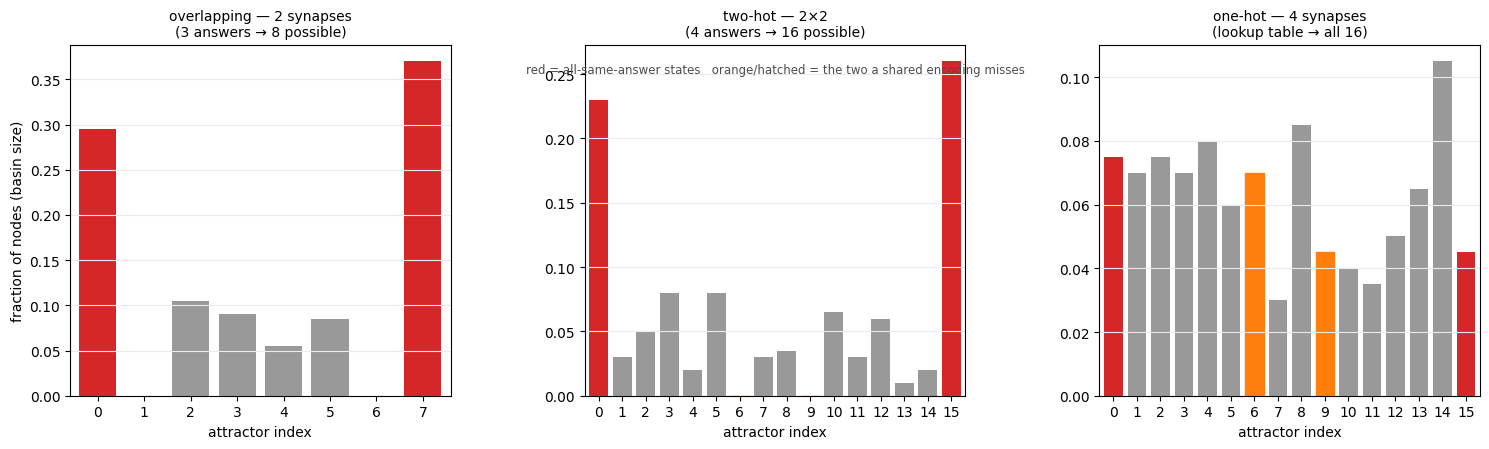

In [12]:
INPUTS = [(0,0), (0,1), (1,0), (1,1)]   # the order that fixes the gate numbering

def id_overlap(seed, n=600):
    # 3 live patterns ([0],[1],[0,1]); (0,0) is not an input. 3-bit fingerprint 0..7.
    core = node_core(2, 'float', 'medium', seed); lane = core.lane(0)
    rng = np.random.default_rng(seed); pats = [P0, P1, P01]
    for _ in range(n):
        p = pats[rng.integers(3)]; lane.evaluate(p,'FF'); lane.evaluate(p,'RU')
    b = [H(lane.evaluate(p,'FFLV')) for p in pats]
    return (b[0] << 2) | (b[1] << 1) | b[2]

def id_twohot(seed, n=600):
    # 2 spaces x 2 channels, AAT = (x0, x1). All four inputs real -> 4-bit gate number 0..15.
    core = Core(1, 2, spaces_per_lane=2, num_lanes=1, model='float', init='medium',
                seed=seed, read_noise=0.0); lane = core.lane(0)
    rng = np.random.default_rng(seed)
    for _ in range(n):
        x = INPUTS[rng.integers(4)]; lane.evaluate(x,'FF'); lane.evaluate(x,'RU')
    o = [H(lane.evaluate(x,'FFLV')) for x in INPUTS]
    return (o[0] << 3) | (o[1] << 2) | (o[2] << 1) | o[3]

def id_onehot(seed, n=600):
    # one space of FOUR synapses; each whole input owns one. Independent -> all 16 reachable.
    core = Core(1, 4, spaces_per_lane=1, num_lanes=1, model='float', init='medium',
                seed=seed, read_noise=0.0); lane = core.lane(0)
    rng = np.random.default_rng(seed); idx = {(0,0):0,(0,1):1,(1,0):2,(1,1):3}
    for _ in range(n):
        x = INPUTS[rng.integers(4)]; lane.evaluate((idx[x],),'FF'); lane.evaluate((idx[x],),'RU')
    o = [H(lane.evaluate((idx[x],),'FFLV')) for x in INPUTS]
    return (o[0] << 3) | (o[1] << 2) | (o[2] << 1) | o[3]

def occupancy(id_fn, n_states, n_trials=200):
    counts = np.zeros(n_states)
    for s in range(n_trials):
        counts[id_fn(s)] += 1
    return counts / n_trials

NONLINEAR = {6, 9}     # XOR / XNOR — not linearly separable, unreachable by a shared lane
CONSTANT  = {0, 15}    # FALSE / TRUE — the all-same-answer "null" constant gates

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
# overlapping: 8 states, its constants are 0 (000) and 7 (111)
occ = occupancy(id_overlap, 8)
ax[0].bar(range(8), occ, color=[RED if i in (0,7) else '0.6' for i in range(8)])
ax[0].set_xticks(range(8)); ax[0].set_xlim(-.6, 7.6)
ax[0].set_title('overlapping — 2 synapses\n(3 answers → 8 possible)', fontsize=10)
ax[0].set_xlabel('attractor index'); ax[0].set_ylabel('fraction of nodes (basin size)')
# two-hot and one-hot: full 16 gate numbers
for col, (id_fn, title) in zip(ax[1:],
        [(id_twohot, 'two-hot — 2×2\n(4 answers → 16 possible)'),
         (id_onehot, 'one-hot — 4 synapses\n(lookup table → all 16)')]):
    occ = occupancy(id_fn, 16)
    cols = [RED if i in CONSTANT else (ORANGE if i in NONLINEAR else '0.6') for i in range(16)]
    bars = col.bar(range(16), occ, color=cols)
    for i in NONLINEAR:
        bars[i].set_hatch('///'); bars[i].set_edgecolor(ORANGE)
    col.set_xticks(range(16)); col.set_xlim(-.6, 15.6)
    col.set_title(title, fontsize=10); col.set_xlabel('attractor index')
for a in ax: a.grid(True, axis='y', color=GRID)
ax[1].text(0.5, 0.92, 'red = all-same-answer states   orange/hatched = the two a shared encoding misses',
           transform=ax[1].transAxes, ha='center', fontsize=8.5, color='0.3')
plt.tight_layout(); plt.show()

Read across the three panels, all with no bias. Overlapping is the null collapse from before:
about two-thirds pile into the two all-same-answer states and several states never form. Two-hot
eases that to about half and spreads the rest. One-hot has no sharing left at all — each input
owns a synapse, so every entry settles independently, the landscape flattens, and every state
fills, including the two that the shared encodings never reach.

So the AATs you push through a lane, worked on by AHaH plasticity, set the whole landscape: which
states exist, how big their basins are, how stable each one is. Change the encoding and the
landscape moves. Add an `RA` bias and it moves again.

## They were logic gates all along

Look again at what a fingerprint is: the sign of the output for every input pattern, written in
order. That is a **truth table**. The number we have been using to tell one attractor from
another is the same number an engineer uses to name a two-input logic gate.

The two giant basins are the **constant** gates FALSE and TRUE — the null states, the laziest
thing a Hebbian node can do. The two states a shared encoding never reaches are **XOR** and
**XNOR**. With two synapses and a bias the output is $y = x_0 w_0 + x_1 w_1 + b$, and the
boundary $y = 0$ is a line: the weights tilt it, the bias slides it, but it stays straight.
A straight line splits any of fourteen gates from the rest — but never XOR, which puts opposite
corners of the input square in the same class. XOR is not missing because the bias is weak; it
is missing because a single node draws one straight line and XOR is not linearly separable.

Give every input its own synapse (one-hot) and the four inputs become four independent axes,
where *every* one of the sixteen functions is separable — XOR and XNOR included. The encoding is
what made them separable, not the node.

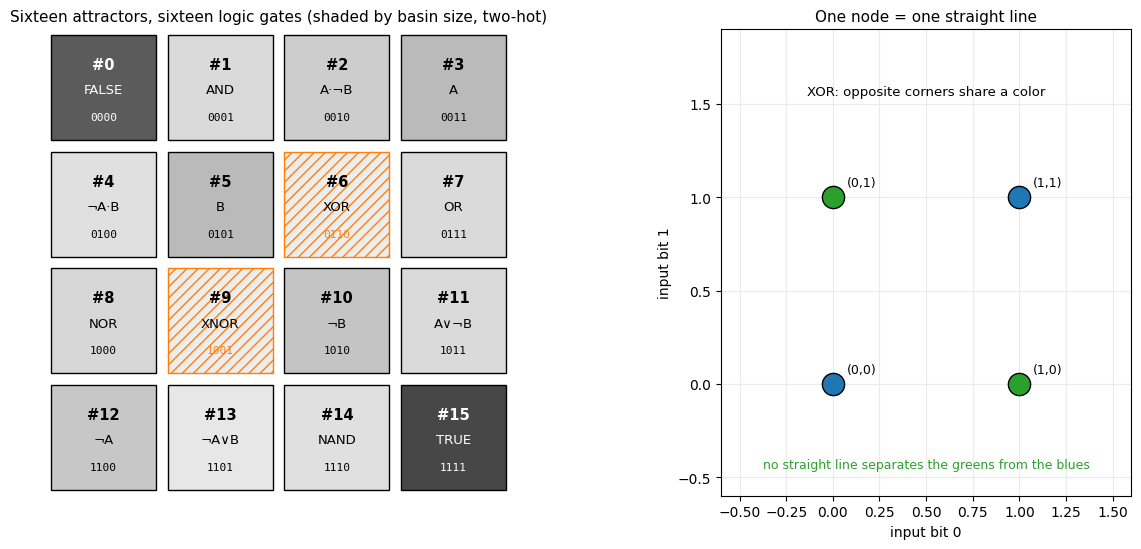

In [13]:
GATE_NAMES = {0:'FALSE',1:'AND',2:'A·¬B',3:'A',4:'¬A·B',5:'B',6:'XOR',7:'OR',
              8:'NOR',9:'XNOR',10:'¬B',11:'A∨¬B',12:'¬A',13:'¬A∨B',14:'NAND',15:'TRUE'}

occ = occupancy(id_twohot, 16)
occ_n = occ / occ.max() if occ.max() > 0 else occ

fig, ax = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={'width_ratios':[1.35, 1]})
a = ax[0]; a.set_xlim(0, 4); a.set_ylim(0, 4); a.set_aspect('equal'); a.axis('off')
a.set_title('Sixteen attractors, sixteen logic gates (shaded by basin size, two-hot)', fontsize=11)
for g in range(16):
    r, c = divmod(g, 4); y = 3 - r; x = c
    shade = 0.93 - 0.65 * occ_n[g]
    rect = Rectangle((x+0.05, y+0.05), 0.9, 0.9, facecolor=(shade,shade,shade), edgecolor='k')
    if g in NONLINEAR: rect.set_hatch('///'); rect.set_edgecolor(ORANGE)
    a.add_patch(rect)
    bits = f'{g>>3&1}{g>>2&1}{g>>1&1}{g&1}'
    txtcol = 'white' if occ_n[g] > 0.6 else 'k'
    a.text(x+0.5, y+0.66, f'#{g}', ha='center', fontsize=10.5, fontweight='bold', color=txtcol)
    a.text(x+0.5, y+0.45, GATE_NAMES[g], ha='center', fontsize=9.5, color=txtcol)
    a.text(x+0.5, y+0.22, bits, ha='center', fontsize=8, family='monospace',
           color=ORANGE if g in NONLINEAR else txtcol)

b = ax[1]; b.set_aspect('equal'); b.set_xlim(-0.6, 1.6); b.set_ylim(-0.6, 1.9)
for (x, y) in INPUTS:
    b.plot(x, y, 'o', ms=16, zorder=3, color=GREEN if (x ^ y) else BLUE,
           markeredgecolor='k', markeredgewidth=1.0)
    b.annotate(f'({x},{y})', (x, y), textcoords='offset points', xytext=(10, 8), fontsize=9)
b.text(0.5, 1.55, 'XOR: opposite corners share a color', ha='center', fontsize=9.5)
b.text(0.5, -0.45, 'no straight line separates the greens from the blues',
       ha='center', fontsize=9, color=GREEN)
b.set_xlabel('input bit 0'); b.set_ylabel('input bit 1')
b.set_title('One node = one straight line', fontsize=11); b.grid(True, color=GRID)
plt.tight_layout(); plt.show()

## What we found

Two kT-bits on a single lane, fed binary patterns, trained with no teacher but their own
output — a forward read, then unsupervised feedback. Orthogonal inputs gave four clean
attractors, each chosen by the luck of the starting conductances. Overlapping inputs pulled most
nodes into the null state, and one state, D, never formed.

Two separate handles opened the rest of the landscape. The **bias** — an always-on synapse
trained against the output with the split write — broke the null state; one bias was enough to
kill it, two with enough magnitude reached every state. The **encoding** reshaped the landscape
on its own, and one-hot went furthest, making all sixteen functions linearly separable at once.

To compare states through all of that, we named each by what it does: the sign of its answer on
every input, read off as a number. That number is a truth table, so every attractor is a logic
function — and nobody designed those gates. They assemble themselves out of the structure of the
input data, worked on by AHaH plasticity, and the hardware and instruction set never changed
through any of it.

The seeds and counts above are there to be changed. Add a label-driven feedback (`FH`/`FL`) and
the same lane becomes a supervised classifier; partition the address space and it becomes many
neurons at once. Same hardware, same instruction set — the next chapters just march different
tuples through it.